In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load 3 datasets
demand = pd.read_parquet("demand.parquet")
metadata = pd.read_parquet("metadata.parquet")
weather = pd.read_parquet("weather.parquet")

In [ ]:
demand.head()

,unique_id,timestamp,y
0,a4077c2f0ac5f939,2012-10-12 00:30:00,0.0
1,a4077c2f0ac5f939,2012-10-12 01:00:00,0.0
2,a4077c2f0ac5f939,2012-10-12 01:30:00,0.0
3,a4077c2f0ac5f939,2012-10-12 02:00:00,0.0
4,a4077c2f0ac5f939,2012-10-12 02:30:00,0.0


In [ ]:
metadata.head()

,unique_id,dataset,building_id,location_id,latitude,longitude,location,timezone,building_class,cluster_size,freq
0,a4077c2f0ac5f939,London Smart Meter Data,MAC000002,gcpvj4cmfb0f,51.52,-0.13,"London, UK",Europe/London,Residential,1,30T
1,c413415b78b2cd28,London Smart Meter Data,MAC000003,gcpvj4cmfb0f,51.52,-0.13,"London, UK",Europe/London,Residential,1,30T
2,4ef97f530574813a,London Smart Meter Data,MAC000004,gcpvj4cmfb0f,51.52,-0.13,"London, UK",Europe/London,Residential,1,30T
3,0c9e78f7ca4842c2,London Smart Meter Data,MAC000005,gcpvj4cmfb0f,51.52,-0.13,"London, UK",Europe/London,Residential,1,30T
4,e881429cbec2cf4d,London Smart Meter Data,MAC000006,gcpvj4cmfb0f,51.52,-0.13,"London, UK",Europe/London,Residential,1,30T


In [ ]:
weather.head()

,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,is_day,sunshine_duration,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,terrestrial_radiation,location_id
0,2011-01-01 00:00:00,4.1265,97.229843,3.7265,1.484439,0.0,0.0,0.0,0.0,3.0,...,0.393,0.393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gcpvj4cmfb0f
1,2011-01-01 01:00:00,4.1765,95.872025,3.5765,1.345968,0.0,0.0,0.0,0.0,3.0,...,0.393,0.393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gcpvj4cmfb0f
2,2011-01-01 02:00:00,3.9265,94.853752,3.1765,0.957560,0.0,0.0,0.0,0.0,3.0,...,0.393,0.393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gcpvj4cmfb0f
3,2011-01-01 03:00:00,3.6765,94.174149,2.8265,0.634312,0.0,0.0,0.0,0.0,3.0,...,0.393,0.393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gcpvj4cmfb0f
4,2011-01-01 04:00:00,3.3765,93.826447,2.4765,0.180433,0.0,0.0,0.0,0.0,3.0,...,0.392,0.392,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gcpvj4cmfb0f


In [ ]:
# Check data info
print("Demand dataset info:")
demand.info()
print("\nMetadata dataset info:")
metadata.info()
print("\nWeather dataset info:")
weather.info()

Demand dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237944171 entries, 0 to 237944170
Data columns (total 3 columns):
 #   Column     Dtype         
---  ------     -----         
 0   unique_id  category      
 1   timestamp  datetime64[ns]
 2   y          float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 4.0 GB

Metadata dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7572 entries, 0 to 7571
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   unique_id       7572 non-null   category
 1   dataset         7572 non-null   category
 2   building_id     7572 non-null   category
 3   location_id     7335 non-null   category
 4   latitude        7335 non-null   float64 
 5   longitude       7335 non-null   float64 
 6   location        7335 non-null   category
 7   timezone        7572 non-null   category
 8   building_class  7572 non-null   category

In [ ]:
# Check data description
print("Demand dataset description:")
display(demand.describe())
print("\nMetadata dataset description:")
display(metadata.describe())
print("\nWeather dataset description:")
display(weather.describe())

Demand dataset description:


,timestamp,y
count,237944171,2.348579e+08
mean,2013-09-06 03:14:57.996664832,4.490447e+01
min,2011-01-01 00:30:00,0.000000e+00
25%,2012-10-30 10:00:00,7.700000e-02
50%,2013-05-20 05:00:00,1.990000e-01
75%,2013-12-14 17:00:00,7.622631e+00
max,2017-12-31 23:00:00,2.212280e+05
std,NaN,3.942504e+02



Metadata dataset description:


,latitude,longitude,cluster_size
count,7335.000000,7335.000000,7572.0
mean,48.755646,-14.083789,1.0
std,5.873737,33.140486,0.0
min,28.520000,-122.260000,1.0
25%,51.520000,-0.130000,1.0
50%,51.520000,-0.130000,1.0
75%,51.520000,-0.130000,1.0
max,53.350000,6.260000,1.0



Weather dataset description:


,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,is_day,sunshine_duration,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,terrestrial_radiation
count,604848,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,...,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000,604848.000000
mean,2016-07-07 06:10:05.094834432,13.043232,72.994255,7.469433,11.199999,0.104439,0.098115,0.004602,0.016962,9.506173,...,14.007569,0.312330,0.320900,0.509329,1230.290649,160.496368,103.807465,56.688900,186.054916,314.664642
min,2011-01-01 00:00:00,-32.200001,2.582063,-36.099998,-37.681385,0.000000,0.000000,0.000000,0.000000,0.000000,...,-15.361000,0.000000,0.027000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-07-31 06:00:00,6.995000,61.185161,2.283000,3.393952,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.600000,0.238000,0.244000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-09-13 01:00:00,13.326500,77.338940,8.599500,11.259397,0.000000,0.000000,0.000000,0.000000,1.000000,...,14.178000,0.341000,0.340000,1.000000,0.000000,7.000000,0.000000,6.000000,0.000000,51.733318
75%,2017-11-07 02:00:00,19.592624,88.816067,13.578000,19.279746,0.000000,0.000000,0.000000,0.000000,3.000000,...,19.842499,0.400000,0.400000,1.000000,3600.000000,262.000000,122.000000,100.000000,333.399094,620.766678
max,2019-01-01 06:00:00,47.613499,100.000000,27.320002,48.003006,33.000000,33.000000,4.270000,0.790000,75.000000,...,43.089500,0.520000,0.520000,1.000000,3600.000000,1079.000000,952.000000,488.000000,1017.039001,1318.578247
std,NaN,9.862261,19.791132,9.148832,11.900755,0.483059,0.476445,0.055332,0.068546,19.555727,...,8.727776,0.123079,0.108136,0.499823,1646.818848,241.076096,188.234879,77.751038,279.753723,398.050812


In [ ]:
# Join demand and metadata on unique_id
demand_metadata = demand.merge(metadata, on="unique_id", how="left")

# Save the data
demand_metadata.to_parquet("demand_metadata.parquet")

In [5]:
# Read data (after restarting kernel)
demand_metadata = pd.read_parquet("demand_metadata.parquet")
weather = pd.read_parquet("weather.parquet")

In [ ]:
# Check info
print("Demand + Metadata dataset info:")
demand_metadata.info()
print("\nWeather dataset info:")
weather.info()

Demand + Metadata dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237944171 entries, 0 to 237944170
Data columns (total 13 columns):
 #   Column          Dtype         
---  ------          -----         
 0   unique_id       object        
 1   timestamp       datetime64[ns]
 2   y               float64       
 3   dataset         category      
 4   building_id     category      
 5   location_id     category      
 6   latitude        float64       
 7   longitude       float64       
 8   location        category      
 9   timezone        category      
 10  building_class  category      
 11  cluster_size    int64         
 12  freq            category      
dtypes: category(7), datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 12.4+ GB

Weather dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604848 entries, 0 to 604847
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------      

In [6]:
# Convert int64 to int32 and float64 to float32 to save memory
for col in demand_metadata.select_dtypes(include=["int64"]).columns:
    demand_metadata[col] = demand_metadata[col].astype("int32")
for col in demand_metadata.select_dtypes(include=["float64"]).columns:
    demand_metadata[col] = demand_metadata[col].astype("float32")

In [17]:
# Count total number of records per year in demand_metadata
demand_metadata["timestamp"].dt.year.value_counts()

timestamp
2013    105175639
2012     72110952
2014     26981039
2016     13861152
2017     13823280
2011      5991739
2015          370
Name: count, dtype: int64

In [18]:
# Count total number of records per year in weather dataset
weather["timestamp"].dt.year.value_counts()

timestamp
2015    140107
2016    131760
2017    131405
2018    131394
2012     17568
2014     17526
2011     17520
2013     17520
2019        48
Name: count, dtype: int64

In [19]:
# Check how many timestamps and location_ids combinations are present in both weather and demand_metadata
print("Unique timestamp and location_id combinations in weather:", weather[["timestamp", "location_id"]].drop_duplicates().shape[0])
print("Unique timestamp and location_id combinations in demand_metadata:", demand_metadata[["timestamp", "location_id"]].drop_duplicates().shape[0])

Unique timestamp and location_id combinations in weather: 604842
Unique timestamp and location_id combinations in demand_metadata: 563398


In [20]:
# Check combinations for 2015 only
print("Unique timestamp and location_id combinations in weather for 2015:", weather[weather["timestamp"].dt.year == 2015][["timestamp", "location_id"]].drop_duplicates().shape[0])
print("Unique timestamp and location_id combinations in demand_metadata for 2015:", demand_metadata[demand_metadata["timestamp"].dt.year == 2015][["timestamp", "location_id"]].drop_duplicates().shape[0])

Unique timestamp and location_id combinations in weather for 2015: 140107
Unique timestamp and location_id combinations in demand_metadata for 2015: 1


In [7]:
# Aggregate demand_metadata
agg_data = (
    demand_metadata.groupby(["timestamp", "location_id"], observed=True)
    .agg(
        y=("y", "sum"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        location=("location", "first"),
        cluster_size=("cluster_size", "first"),
    )
    .reset_index()
)

In [8]:
# Join weather and demand_metadata on timestamp and location_id
# full_data = weather.merge(demand_metadata, on=["timestamp", "location_id"], how="inner")
full_data = weather.merge(agg_data, on=["timestamp", "location_id"], how="left")

# Check head
full_data.head()

,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,direct_radiation,diffuse_radiation,direct_normal_irradiance,terrestrial_radiation,location_id,y,latitude,longitude,location,cluster_size
0,2011-01-01 00:00:00,4.1265,97.229843,3.7265,1.484439,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,gcpvj4cmfb0f,NaN,NaN,NaN,NaN,NaN
1,2011-01-01 01:00:00,4.1765,95.872025,3.5765,1.345968,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,gcpvj4cmfb0f,NaN,NaN,NaN,NaN,NaN
2,2011-01-01 02:00:00,3.9265,94.853752,3.1765,0.957560,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,gcpvj4cmfb0f,NaN,NaN,NaN,NaN,NaN
3,2011-01-01 03:00:00,3.6765,94.174149,2.8265,0.634312,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,gcpvj4cmfb0f,NaN,NaN,NaN,NaN,NaN
4,2011-01-01 04:00:00,3.3765,93.826447,2.4765,0.180433,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,gcpvj4cmfb0f,NaN,NaN,NaN,NaN,NaN


In [9]:
# Separate timestamp into several temporal columns
full_data["timestamp"] = pd.to_datetime(full_data["timestamp"])
full_data["hour"] = full_data["timestamp"].dt.hour
full_data["day"] = full_data["timestamp"].dt.day
full_data["month"] = full_data["timestamp"].dt.month
full_data["year"] = full_data["timestamp"].dt.year

# Check full data info
print("Full data info:")
full_data.info()

Full data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604848 entries, 0 to 604847
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   timestamp                   604848 non-null  datetime64[ns]
 1   temperature_2m              604848 non-null  float32       
 2   relative_humidity_2m        604848 non-null  float32       
 3   dew_point_2m                604848 non-null  float32       
 4   apparent_temperature        604848 non-null  float32       
 5   precipitation               604848 non-null  float32       
 6   rain                        604848 non-null  float32       
 7   snowfall                    604848 non-null  float32       
 8   snow_depth                  604848 non-null  float32       
 9   weather_code                604848 non-null  float32       
 10  pressure_msl                604848 non-null  float32       
 11  surface_pressure       

In [10]:
# Check null values in full_data
print("Null values in full_data:")
print(full_data.isnull().sum())

Null values in full_data:
timestamp                          0
temperature_2m                     0
relative_humidity_2m               0
dew_point_2m                       0
apparent_temperature               0
precipitation                      0
rain                               0
snowfall                           0
snow_depth                         0
weather_code                       0
pressure_msl                       0
surface_pressure                   0
cloud_cover                        0
cloud_cover_low                    0
cloud_cover_mid                    0
cloud_cover_high                   0
et0_fao_evapotranspiration         0
vapour_pressure_deficit            0
wind_speed_10m                     0
wind_direction_10m                 0
wind_gusts_10m                     0
soil_temperature_0_to_7cm          0
soil_temperature_7_to_28cm         0
soil_moisture_0_to_7cm             0
soil_moisture_7_to_28cm            0
is_day                             0
sunshine_dur

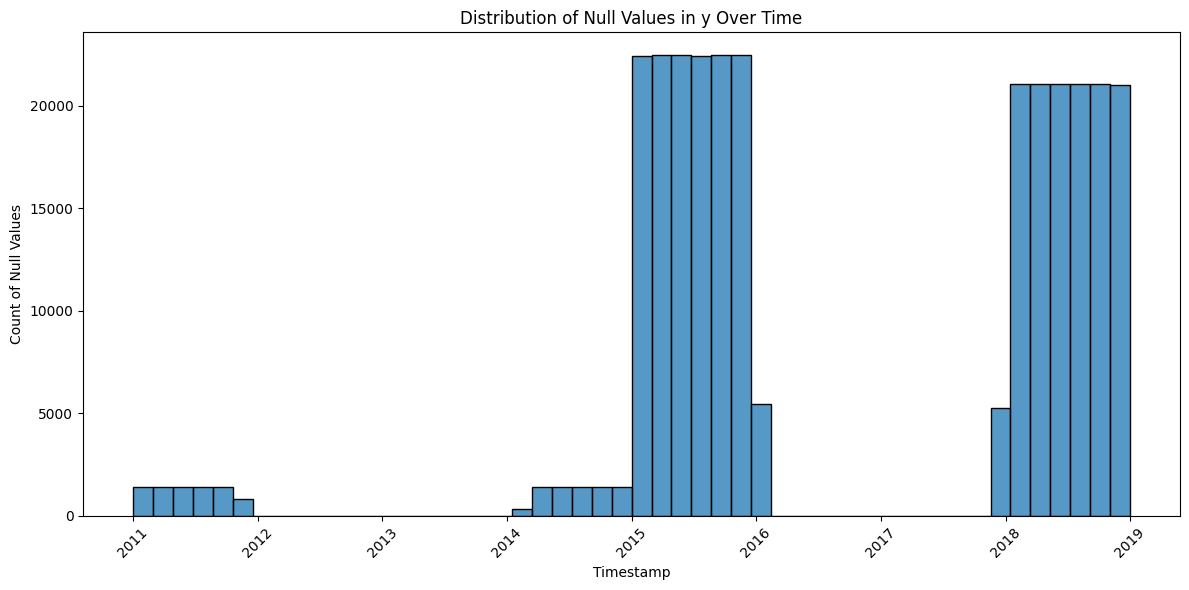

In [11]:
full_data_y_null = full_data[full_data["y"].isnull()]
# Chech time distribution of null values in y
plt.figure(figsize=(12, 6))
sns.histplot(full_data_y_null["timestamp"], bins=50, kde=False)
plt.title("Distribution of Null Values in y Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Count of Null Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

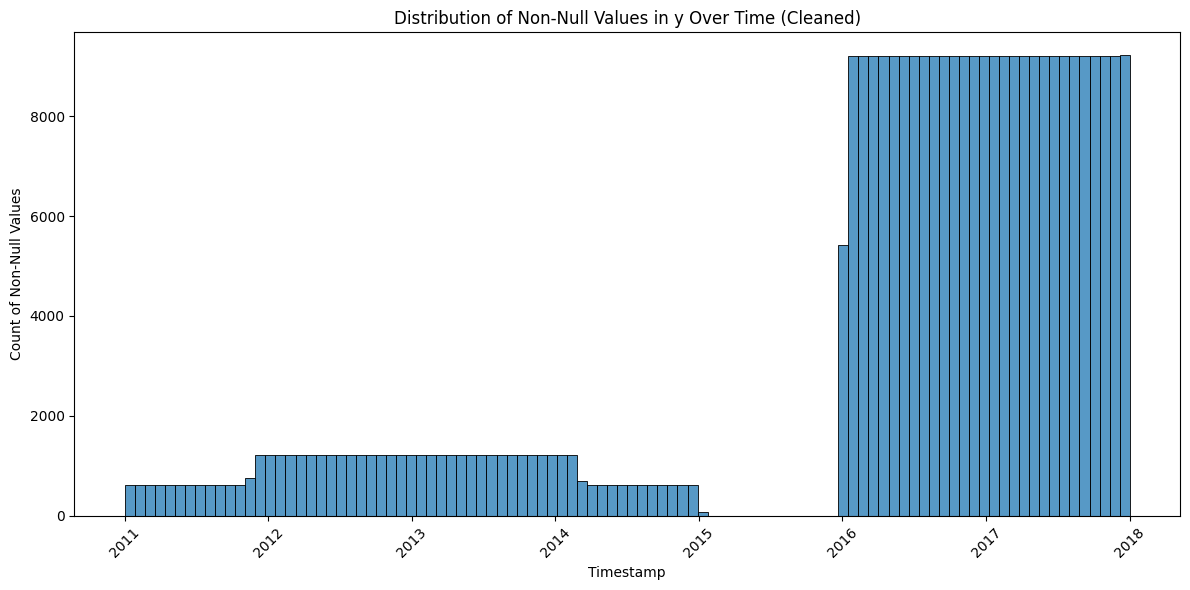

In [12]:
# Drop the null values in y to a new data
full_data_non_null = full_data[full_data["y"].notnull()].reset_index(drop=True)

# Check time distribution of non-null values in y
plt.figure(figsize=(12, 6))
sns.histplot(full_data_non_null["timestamp"], bins=100, kde=False)
plt.title("Distribution of Non-Null Values in y Over Time (Cleaned)")
plt.xlabel("Timestamp")
plt.ylabel("Count of Non-Null Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Make a separate dataset for years 2016-recent
full_data_2016_onwards = full_data_non_null[full_data_non_null["year"] >= 2016].reset_index(drop=True)

# Save both datasets
full_data_non_null.to_csv("full_data_non_null.csv", index=False)
full_data_2016_onwards.to_csv("full_data_2016_onwards.csv", index=False)
# parquet version
full_data_non_null.to_parquet("full_data_non_null.parquet", index=False)
full_data_2016_onwards.to_parquet("full_data_2016_onwards.parquet", index=False)

In [14]:
full_data_2016_onwards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263165 entries, 0 to 263164
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   timestamp                   263165 non-null  datetime64[ns]
 1   temperature_2m              263165 non-null  float32       
 2   relative_humidity_2m        263165 non-null  float32       
 3   dew_point_2m                263165 non-null  float32       
 4   apparent_temperature        263165 non-null  float32       
 5   precipitation               263165 non-null  float32       
 6   rain                        263165 non-null  float32       
 7   snowfall                    263165 non-null  float32       
 8   snow_depth                  263165 non-null  float32       
 9   weather_code                263165 non-null  float32       
 10  pressure_msl                263165 non-null  float32       
 11  surface_pressure            263165 non-

In [2]:
# read data
full_data_2016_onwards = pd.read_parquet("full_data_2016_onwards.parquet")
full_data_2016_onwards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263165 entries, 0 to 263164
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   timestamp                   263165 non-null  datetime64[ns]
 1   temperature_2m              263165 non-null  float32       
 2   relative_humidity_2m        263165 non-null  float32       
 3   dew_point_2m                263165 non-null  float32       
 4   apparent_temperature        263165 non-null  float32       
 5   precipitation               263165 non-null  float32       
 6   rain                        263165 non-null  float32       
 7   snowfall                    263165 non-null  float32       
 8   snow_depth                  263165 non-null  float32       
 9   weather_code                263165 non-null  float32       
 10  pressure_msl                263165 non-null  float32       
 11  surface_pressure            263165 non-

In [12]:
full_data_2016_onwards['cloud_cover'].value_counts()

cloud_cover
100.000000    50933
0.000000      36410
90.000000      4420
0.900000       2296
30.000002      2048
              ...  
42.600006         1
36.299995         1
36.900005         1
45.600006         1
63.000008         1
Name: count, Length: 923, dtype: int64

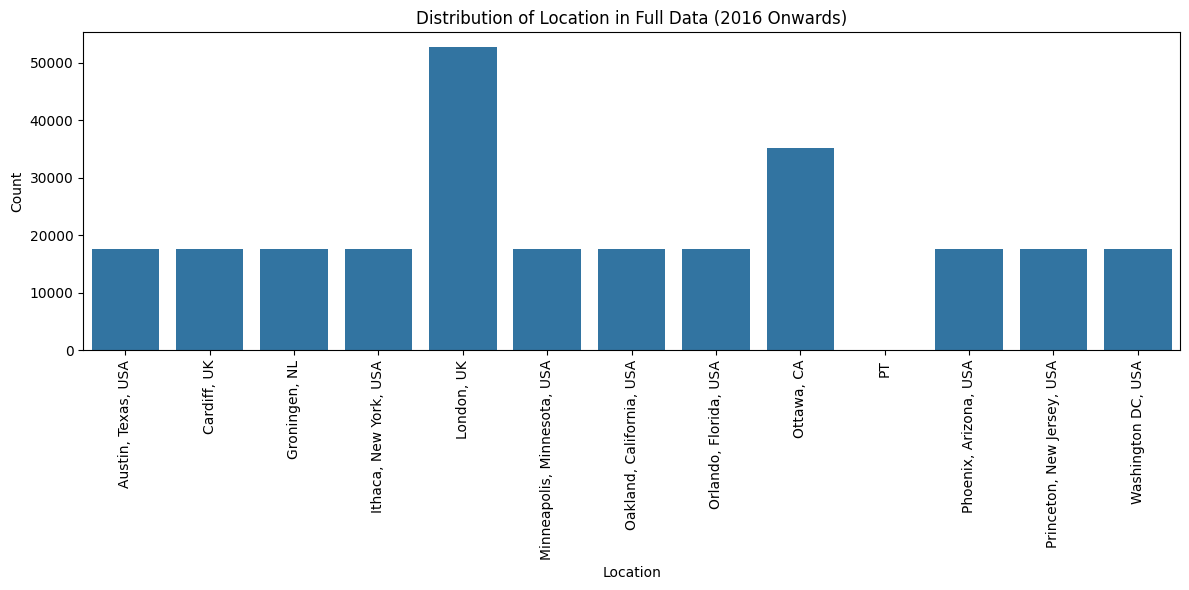

In [4]:
# check distribution of location
plt.figure(figsize=(12, 6))
sns.countplot(x="location", data=full_data_2016_onwards)
plt.title("Distribution of Location in Full Data (2016 Onwards)")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()